In [2]:
from ultralytics import YOLO 
model = YOLO('yolo11n.pt')  

In [2]:
from ultralytics import YOLO 
 
# 1. Cargar un modelo pre-entrenado (YOLOv8 nano es rápido y ligero) 
model = YOLO('yolo11n.pt')  
 
# 2. Entrenar el modelo 
results = model.train( 
    data='bbox-retail.v1i.yolov11/data.yaml',  
    epochs=20,                # Número de vueltas al dataset 
    imgsz=640,                # Tamaño de la imagen 
    plots=True,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.11 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16083MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=bbox-retail.v1i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, n

Resultados en: runs/detect/train2

Visualizaciones

Curvas de entrenamiento:


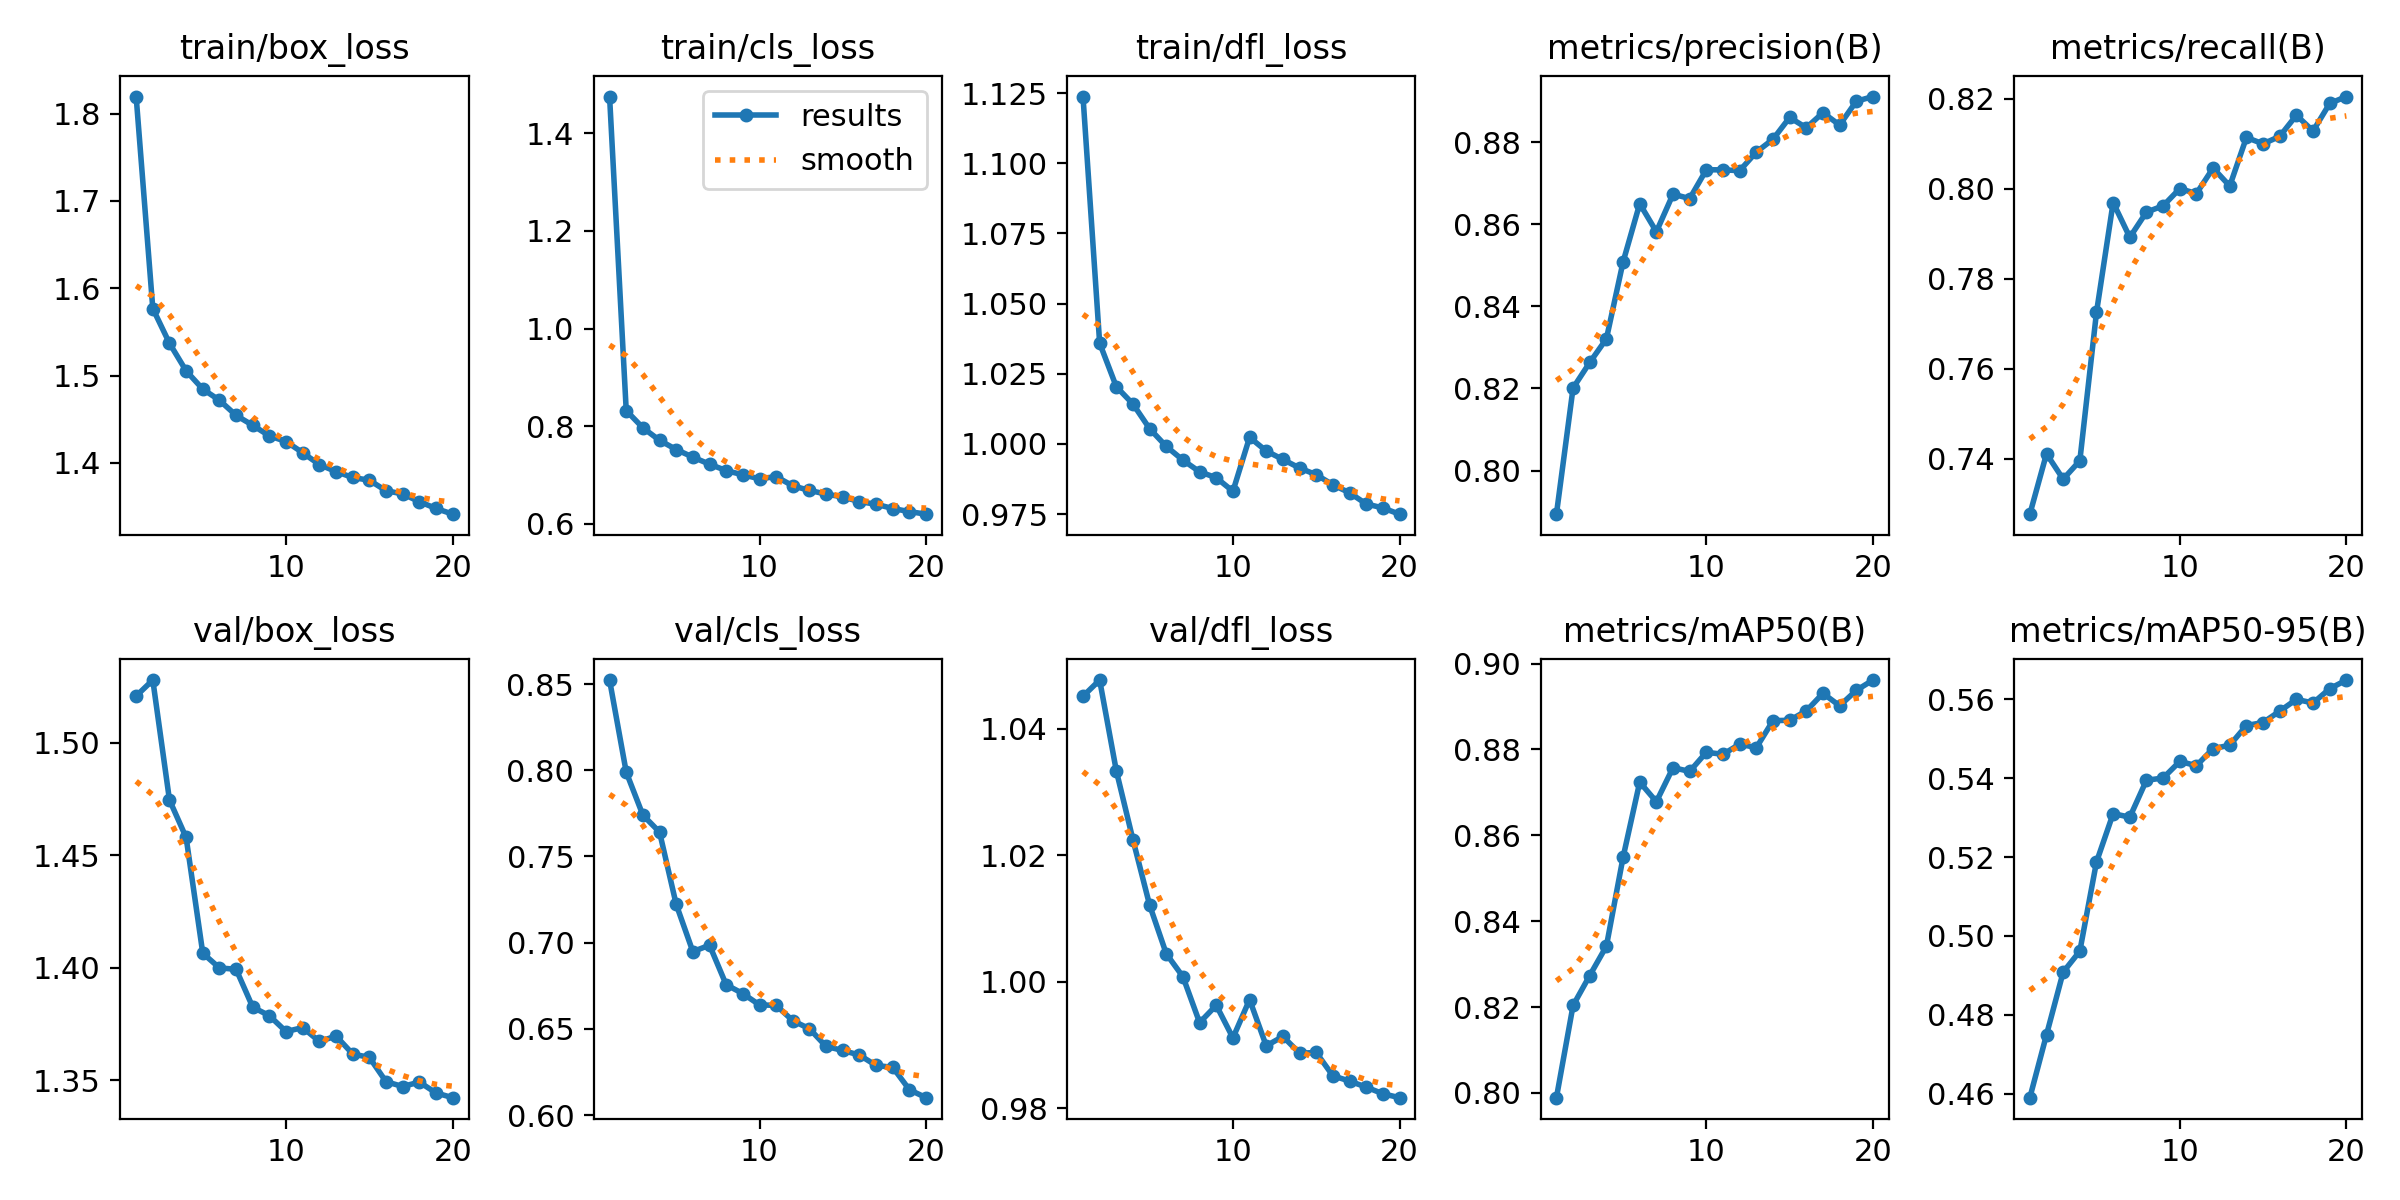


Predicciones de validación:


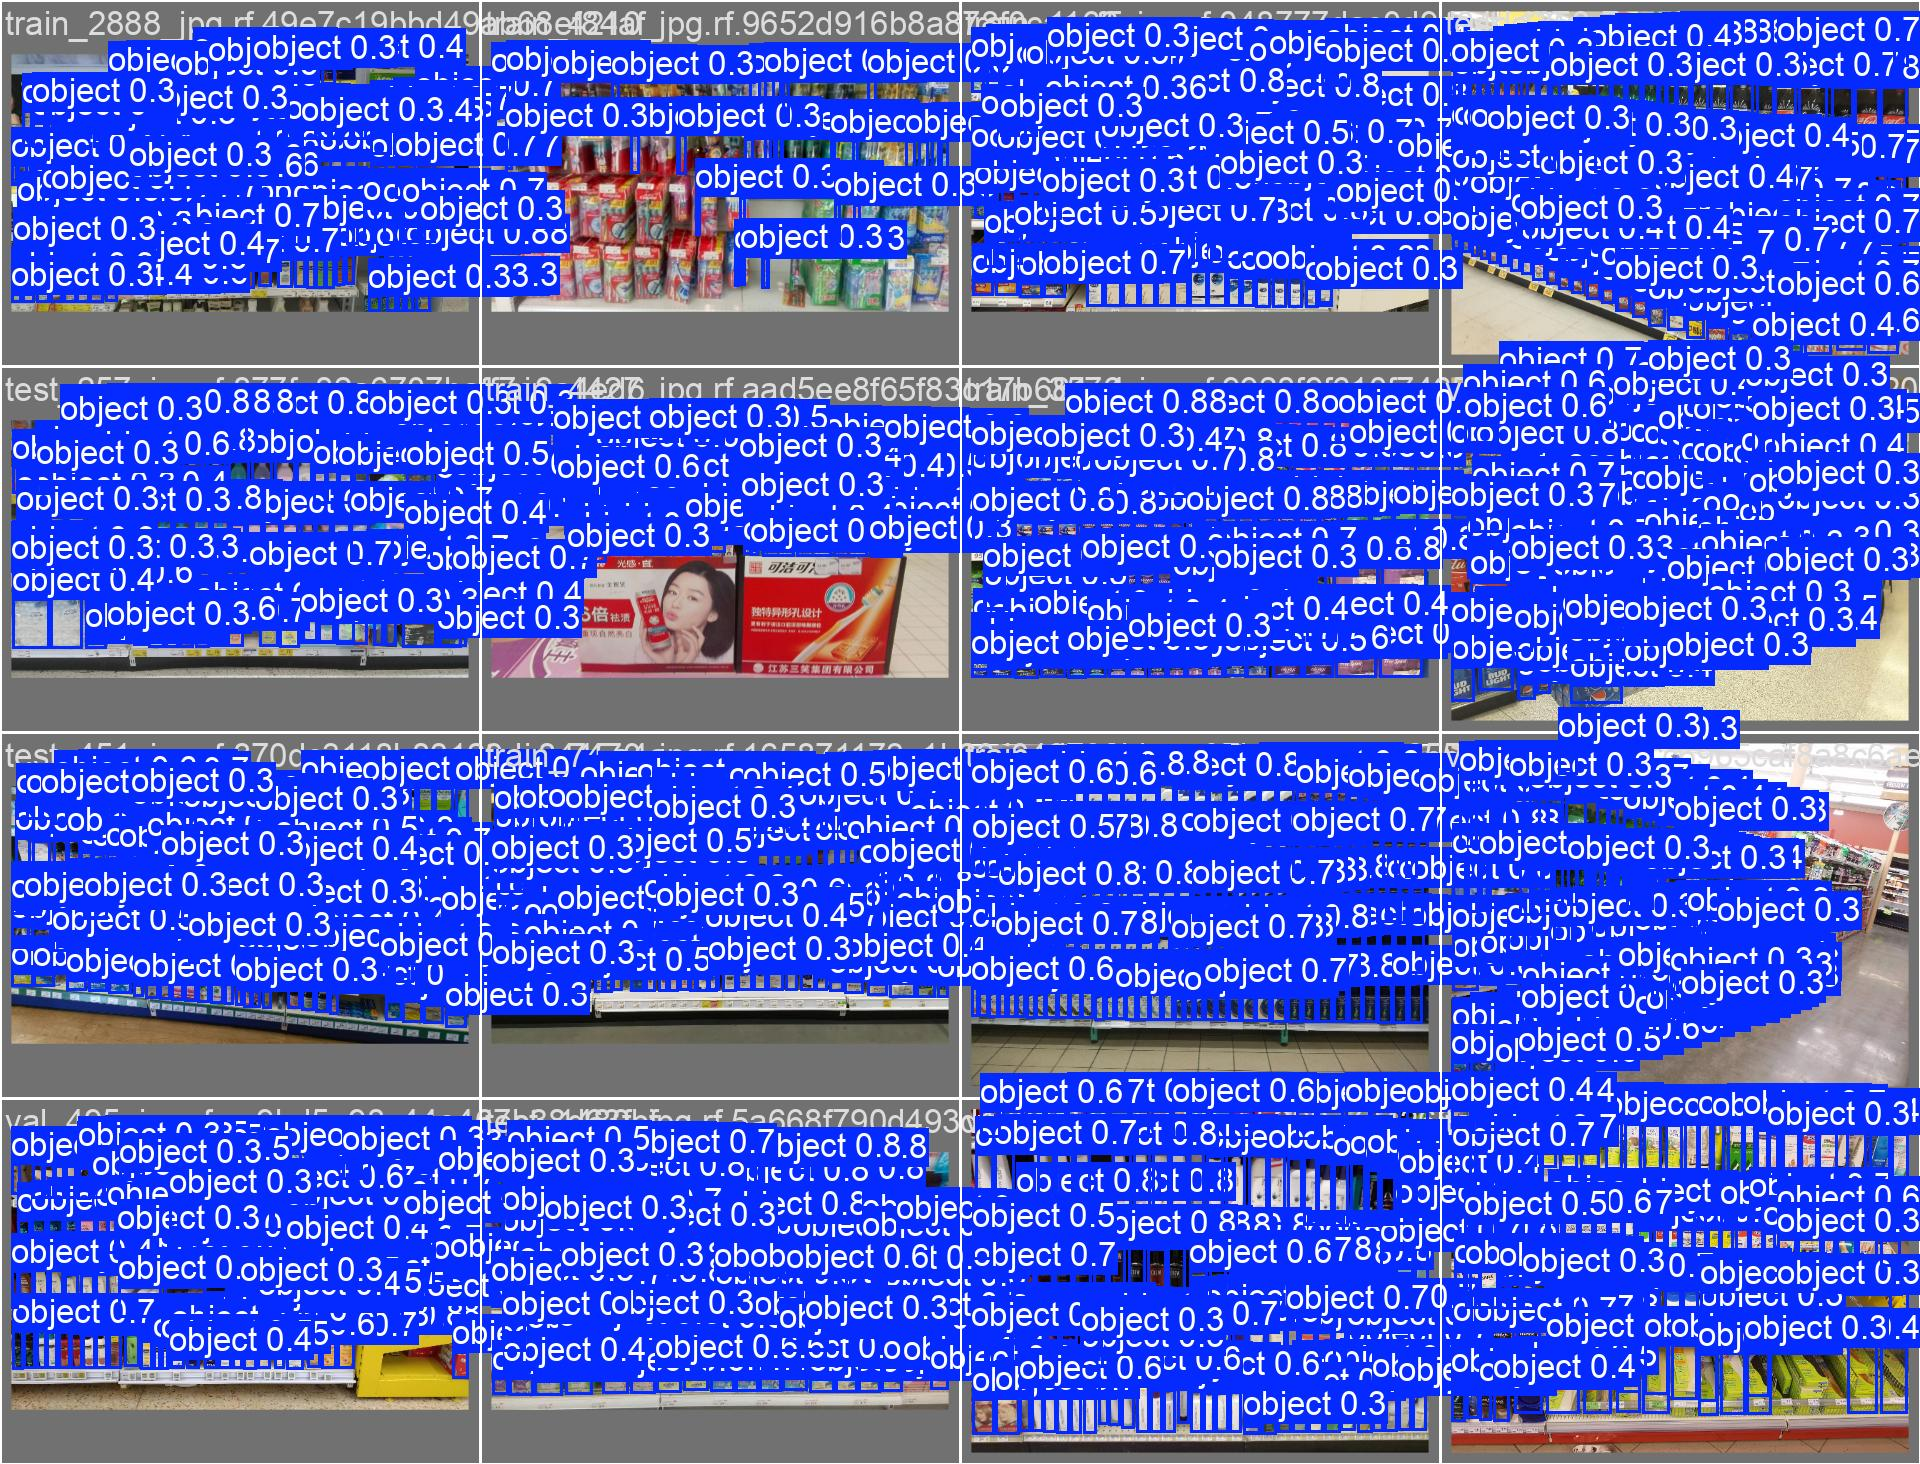


Ground Truth:


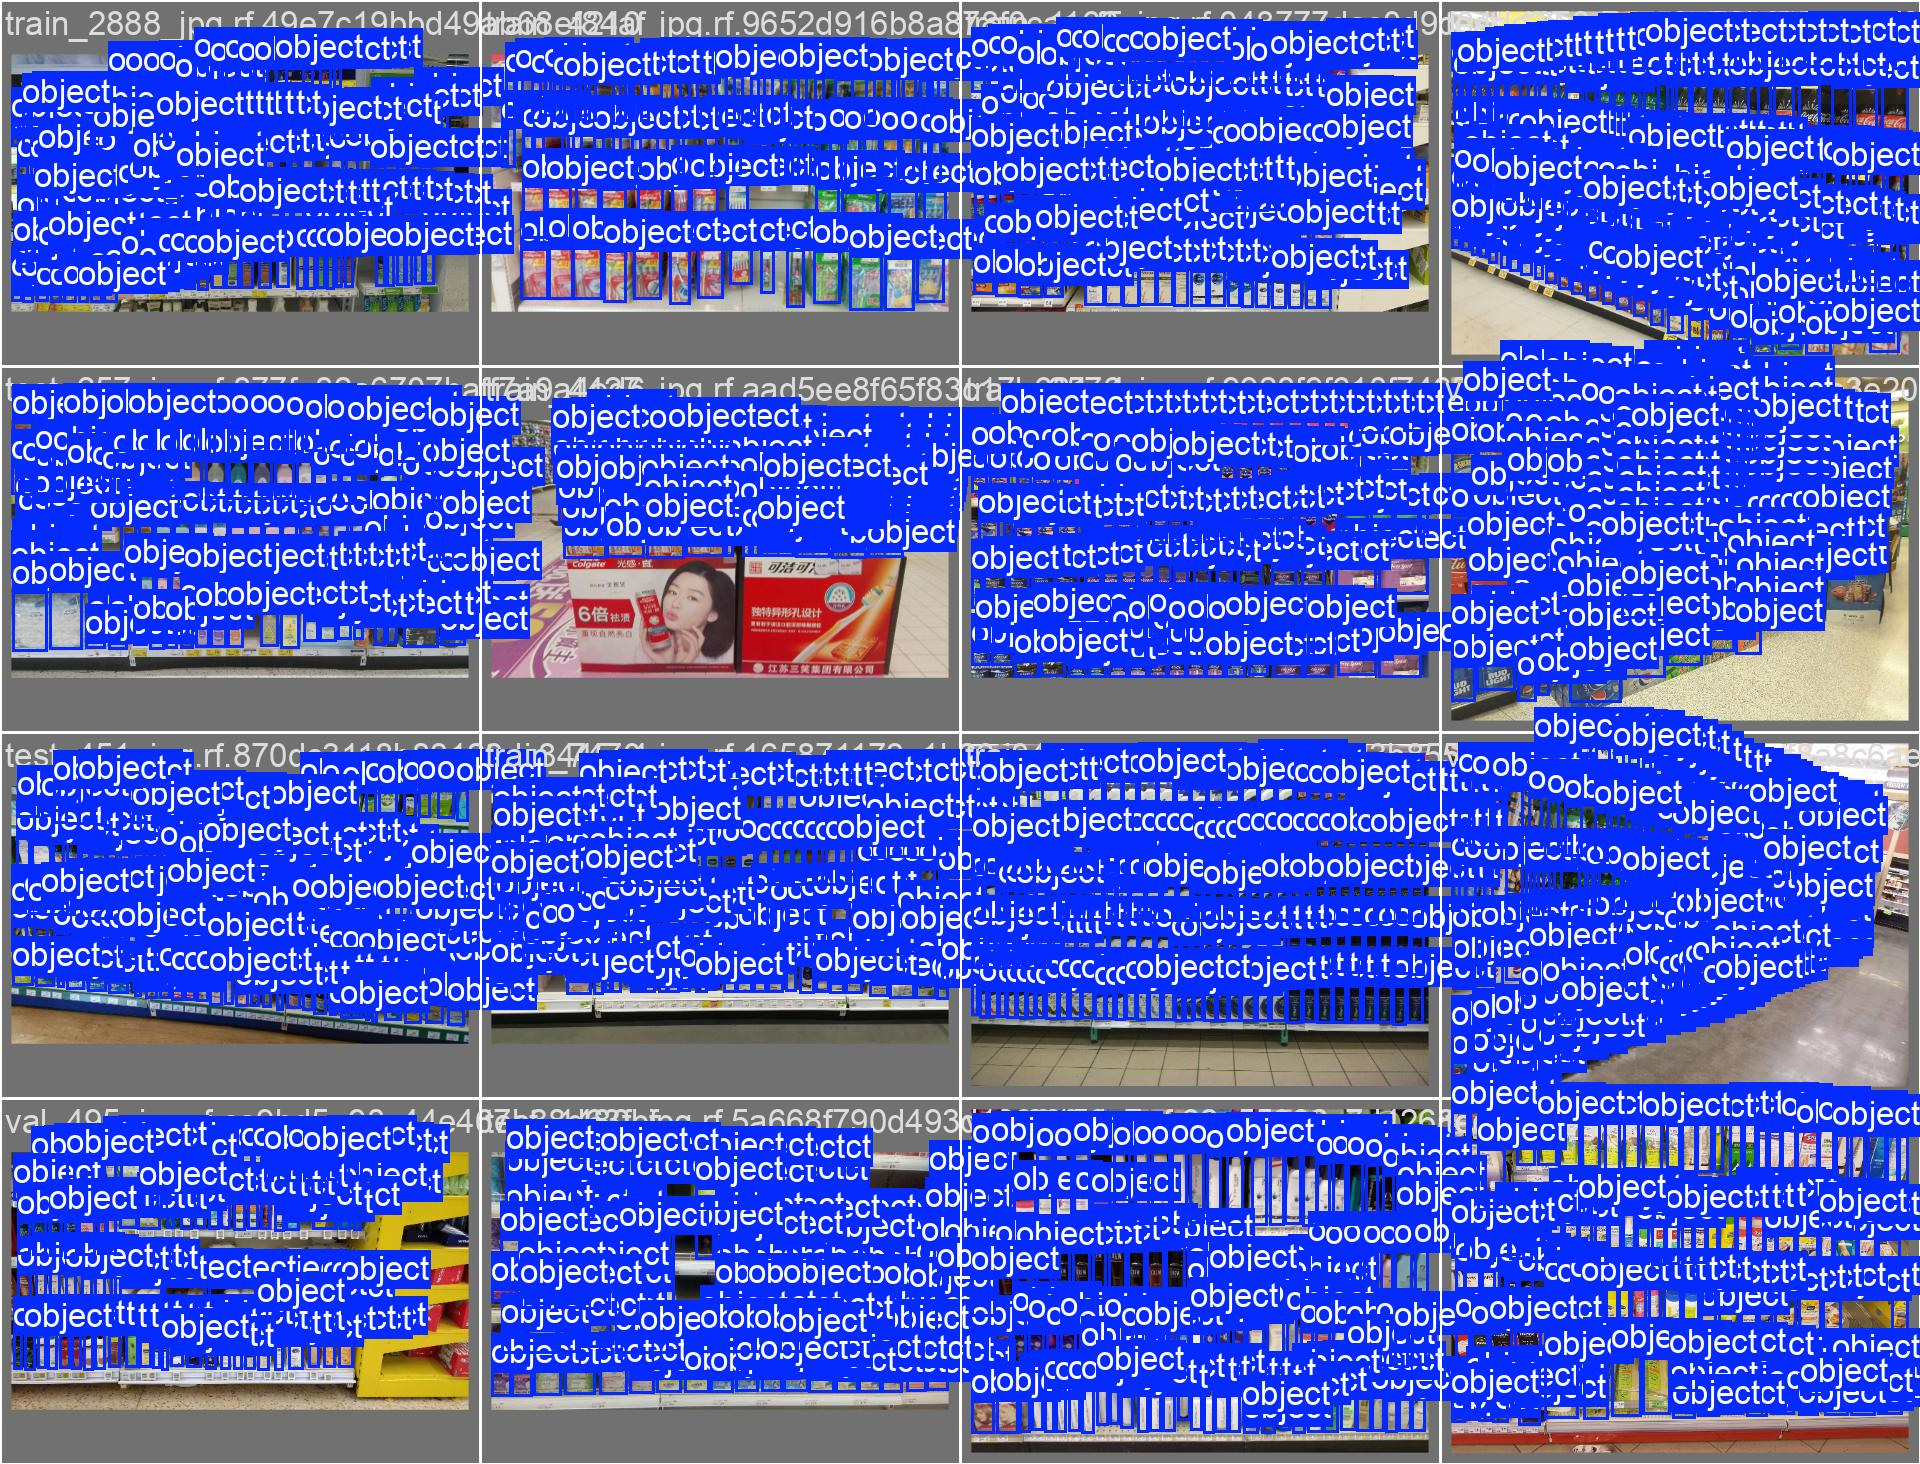


Matriz de confusión:


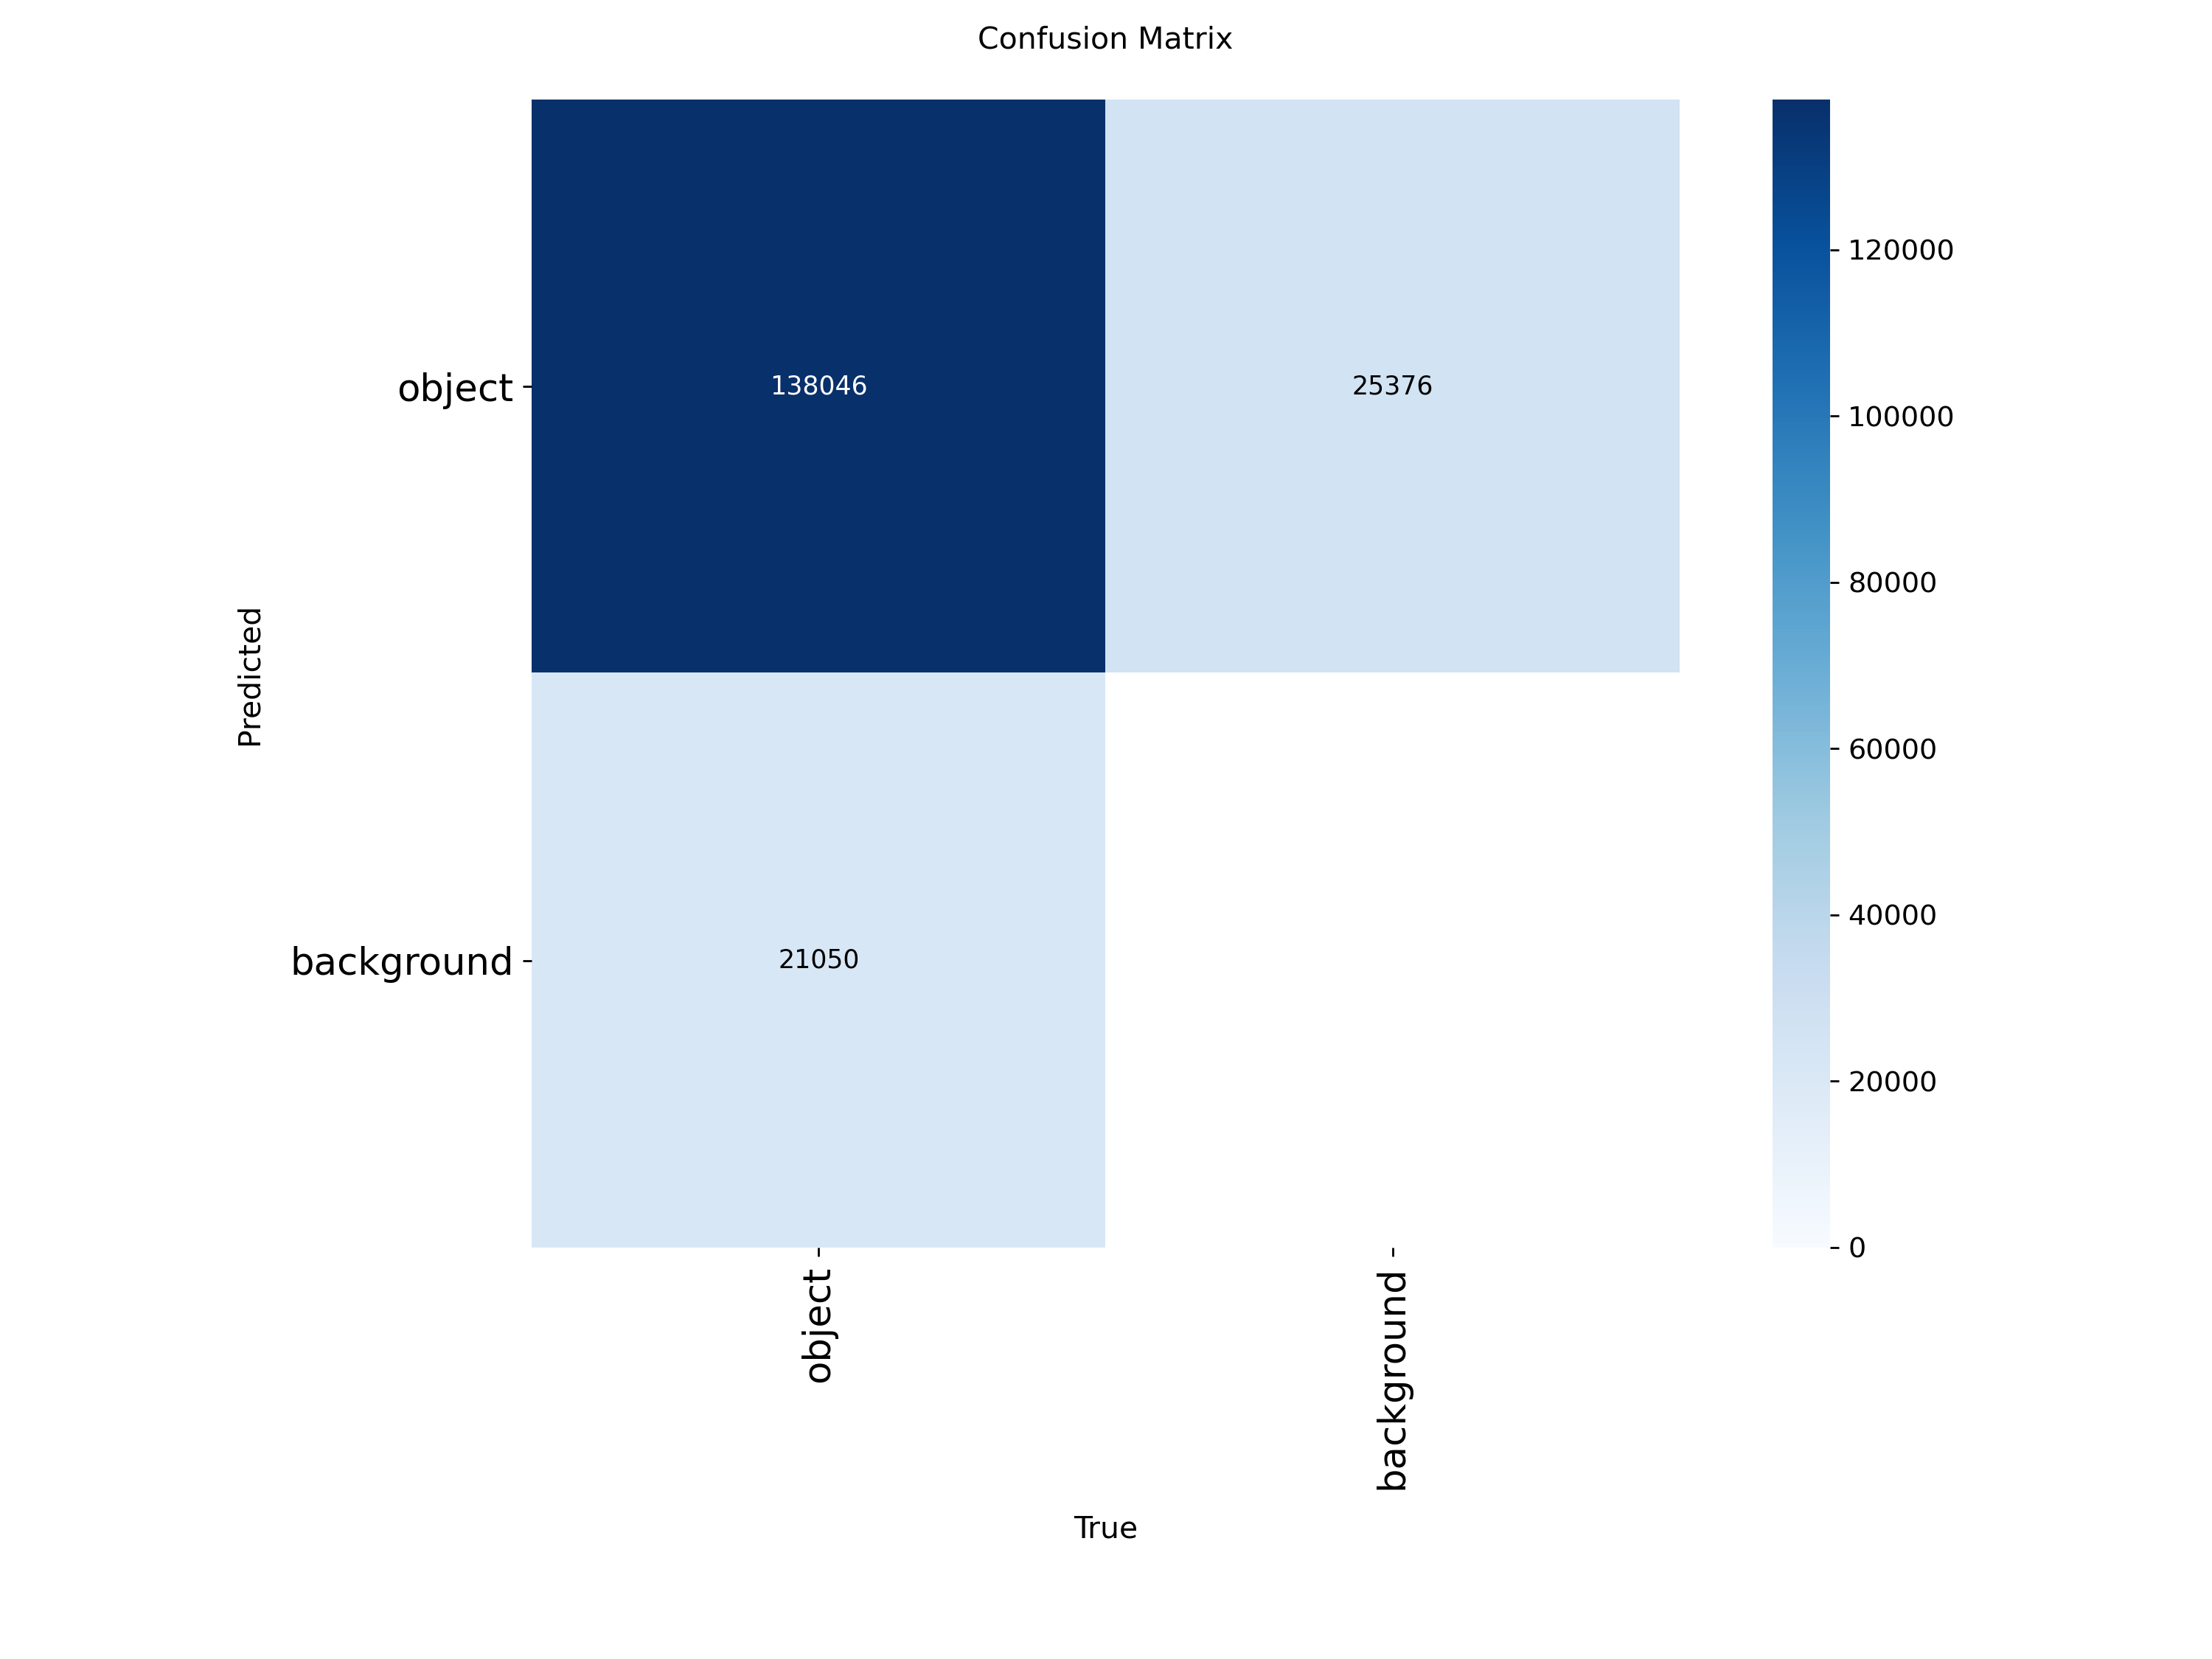

Metricas

Época final: 20
mAP50 (Detección): 0.8962
mAP50-95 (Detección): 0.5649

Entrenamiento completado
Mejor modelo guardado en: runs/detect/train2/weights/best.pt


In [3]:
import os
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

# Ruta a resultados
results_path = f'runs/detect/train2'

print(f"Resultados en: {results_path}\n")

# Mostrar imágenes principales
print("Visualizaciones")

imgs = {
    'Curvas de entrenamiento': 'results.png',
    'Predicciones de validación': 'val_batch0_pred.jpg',
    'Ground Truth': 'val_batch0_labels.jpg',
    'Matriz de confusión': 'confusion_matrix.png'
}

for titulo, archivo in imgs.items():
    path = f'{results_path}/{archivo}'
    if os.path.exists(path):
        print(f"\n{titulo}:")
        display(Image(filename=path, width=800))

# Métricas finales
print("Metricas")

df = pd.read_csv(f'{results_path}/results.csv')
ultima_epoca = df.iloc[-1]

print(f"\nÉpoca final: {int(ultima_epoca['epoch'])}")
print(f"mAP50 (Detección): {ultima_epoca['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95 (Detección): {ultima_epoca['metrics/mAP50-95(B)']:.4f}")
#print(f"mAP50 (Segmentación): {ultima_epoca['metrics/mAP50(M)']:.4f}")
#print(f"mAP50-95 (Segmentación): {ultima_epoca['metrics/mAP50-95(M)']:.4f}")

print("\nEntrenamiento completado")
print(f"Mejor modelo guardado en: {results_path}/weights/best.pt")

In [17]:
model = YOLO('runs/detect/train2/weights/best.pt')

img_path = 'bbox-retail.v1i.yolov11/test/images/test_1142_jpg.rf.3dbb7595269b6b2ce74700953783d665.jpg'

resultados = model(img_path)

print(f"Objetos detectados inicialmente: {len(resultados[0].boxes)}")


image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/Actividad3_6 ConteoObjetos/bbox-retail.v1i.yolov11/test/images/test_1142_jpg.rf.3dbb7595269b6b2ce74700953783d665.jpg: 640x384 206 objects, 2.8ms
Speed: 1.4ms preprocess, 2.8ms inference, 26.9ms postprocess per image at shape (1, 3, 640, 384)
Objetos detectados inicialmente: 206


In [18]:
from collections import Counter

UMBRAL_CONF = 0.4

prediccion = resultados[0]
cajas_totales = prediccion.boxes

boxes_filtradas = [box for box in cajas_totales if box.conf > UMBRAL_CONF]

print(f"Objetos reales tras filtrar: {len(boxes_filtradas)}")

ids_clases = [int(box.cls) for box in boxes_filtradas]

conteos = Counter(ids_clases)

print("\nREPORTE DE INVENTARIO:")
nombres_clases = model.names

for clase_id, cantidad in conteos.items():
    nombre_obj = nombres_clases[clase_id]
    print(f" -> {nombre_obj}: {cantidad} unidades")


Objetos reales tras filtrar: 170

REPORTE DE INVENTARIO:
 -> object: 170 unidades


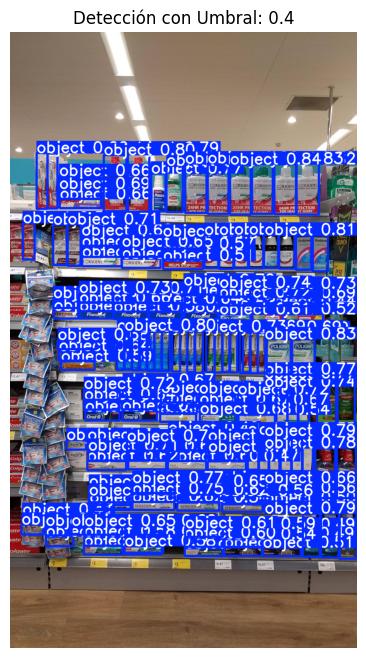

In [19]:
import cv2
import matplotlib.pyplot as plt

def visualizar_conteo(prediccion, boxes_filtradas, conteos, umbral):

    prediccion.boxes = prediccion.boxes[prediccion.boxes.conf > umbral]
    img_resultado = prediccion.plot()

    img_rgb = cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Detección con Umbral: {umbral}")
    plt.show()

visualizar_conteo(resultados[0], boxes_filtradas, conteos, UMBRAL_CONF)


In [5]:
def analizar_estanteria(ruta_imagen, modelo, umbral=0.4):
    resultados = modelo(ruta_imagen)
    pred = resultados[0]

    boxes_filtradas = [box for box in pred.boxes if box.conf > umbral]

    return len(boxes_filtradas)


In [21]:
analizar_estanteria("bbox-retail.v1i.yolov11/test/images/test_1142_jpg.rf.3dbb7595269b6b2ce74700953783d665.jpg", model)


image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/Actividad3_6 ConteoObjetos/bbox-retail.v1i.yolov11/test/images/test_1142_jpg.rf.3dbb7595269b6b2ce74700953783d665.jpg: 640x384 206 objects, 3.0ms
Speed: 2.9ms preprocess, 3.0ms inference, 26.9ms postprocess per image at shape (1, 3, 640, 384)


170

In [ ]:
import glob

rutas_test = glob.glob("drinks.v1i.yolov11/test/images/*.jpg")
print(rutas_test)
for ruta in rutas_test[:3]:
    total = analizar_estanteria(ruta, model)
    print(f"Imagen: {ruta}")
    print(f"Total productos detectados: {total}\n")


['drinks.v1i.yolov11/test/images/image_166_jpg.rf.c060a83c6426d25b75c2cb663873b6d0.jpg', 'drinks.v1i.yolov11/test/images/image_162_jpg.rf.8223373bf2ea60e4e91c46a15c32507f.jpg', 'drinks.v1i.yolov11/test/images/107_jpg.rf.b9c49d9d769488889c4f964fc12396d7.jpg', 'drinks.v1i.yolov11/test/images/40_jpg.rf.2a46e0d9abe1c2150f536dacd736f658.jpg', 'drinks.v1i.yolov11/test/images/image_97_jpg.rf.f7f8c4c14ee7e7ae9a26a724fb703739.jpg', 'drinks.v1i.yolov11/test/images/image_109_jpg.rf.f3d5c258de0cc1b529752a3de7c14019.jpg', 'drinks.v1i.yolov11/test/images/19_jpg.rf.768f4668aad6a0142f86bfc51eae75de.jpg', 'drinks.v1i.yolov11/test/images/11_jpg.rf.c2c3668090a43c328fe4a24ff31d83fd.jpg', 'drinks.v1i.yolov11/test/images/92_jpg.rf.9bf71647d2579e978d3334060acc7bce.jpg', 'drinks.v1i.yolov11/test/images/17_jpg.rf.1c5c6ad84cb7dea7c406c86e0c12321c.jpg', 'drinks.v1i.yolov11/test/images/image_37_jpg.rf.94b2e9bba1d43568e623f5ee41268229.jpg', 'drinks.v1i.yolov11/test/images/image_154_jpg.rf.5dcf2d0c379dde492aaf0eb50